In [1]:
from spatial_guidance import PipelineConfig, StrayDatasetConfig, StrayScannerDataParserConfig, StrayScannerPaths
from utils import CONSOLE

import os
os.environ["ZENML_STORE_BACKUP_STRATEGY"] = "disabled"

In [3]:
pipeline_config = PipelineConfig(
    stack="default",
    # stack="airflow_stack",
    dataset_config=StrayDatasetConfig(
        data_parser_config=StrayScannerDataParserConfig(
            paths=StrayScannerPaths(
                dataset_dir="SmartAIs Recorded Data/baustelle"  # relative to root/.data
            )
        ),
        is_rotated=True,
        verbose=False,
    ),
    enable_cache_global=False,
    enable_artifact_metadata_global=True,
)


Activated ZenML stack: default

In [9]:
pipeline = pipeline_config.setup_target()
ret = pipeline(400, None)
print(ret)

Initialized Gemini detector with model: gemini-2.0-flash

Initialized SceneVisualizer with debug=False

Initiating a new run for the pipeline: SpatialUnderstandingPipeline.
Not including stack component settings with key orchestrator.local.
Not including stack component settings with key orchestrator.local.
Not including stack component settings with key orchestrator.local.
Caching is disabled by default for SpatialUnderstandingPipeline.
Using user: default
Using stack: default
  orchestrator: default
  artifact_store: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.


Warning: No config provided for StrayDataset, using default config.
  File "/opt/homebrew/Caskroom/miniconda/base/envs/dlvc/lib/python3.11/site-packages/zenml/steps/base_step.py", line 
244, in load_from_source
    return obj()
  File 
"/Users/jd/Desktop/repos/dlvc-04-spatial-understanding/src/spatial_guidance/spatial_guidance/data_handling/stray_scanner
/stray_dataset.py", line 62, in __init__
    CONSOLE.warn("No config provided for StrayDataset, using default config.")

Warning: No config provided for StrayDataset, using default config.
  File "/opt/homebrew/Caskroom/miniconda/base/envs/dlvc/lib/python3.11/site-packages/zenml/steps/base_step.py", line 
244, in load_from_source
    return obj()
  File 
"/Users/jd/Desktop/repos/dlvc-04-spatial-understanding/src/spatial_guidance/spatial_guidance/data_handling/stray_scanner
/stray_dataset.py", line 62, in __init__
    CONSOLE.warn("No config provided for StrayDataset, using default config.")

...

Step GeminiVLMDetection has finished in 5.872s.
Step get_visualization_in has started.
Step get_visualization_in has finished in 0.265s.


Initialized SceneVisualizer with debug=False

Step SceneVisualizer has started.


Initialized SceneVisualizer with debug=False

Step SceneVisualizer has finished in 0.765s.
Pipeline run has finished in 7.313s.
body=PipelineRunResponseBody(created=datetime.datetime(2025, 4, 29, 10, 9, 44, 870660), updated=datetime.datetime(2025, 4, 29, 10, 9, 52, 220433), user=UserResponse(body=UserResponseBody(created=datetime.datetime(2025, 4, 29, 9, 41, 33, 690428), updated=datetime.datetime(2025, 4, 29, 9, 41, 33, 690436), active=True, activation_token=None, full_name='', email_opted_in=None, is_service_account=False, is_admin=True, default_project_id=None), metadata=None, resources=None, id=UUID('4a9eac24-3368-4c63-8d4a-8820c123290e'), permission_denied=False, name='default'), status=<ExecutionStatus.COMPLETED: 'completed'>, stack=StackResponse(body=StackResponseBody(created=datetime.datetime(2025, 4, 29, 9, 41, 33, 402760), updated=datetime.datetime(2025, 4, 29, 9, 41, 33, 402766), user=None), metadata=None, resources=None, id=UUID('1d5d9420-6acb-4f5a-acc3-65e8886d6dea'), permission_denied=False, name='default'), pipeline=

VisualizationOut(
    visualization=<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=1218x690 at 0x300277490>,
    object_count=5,
)

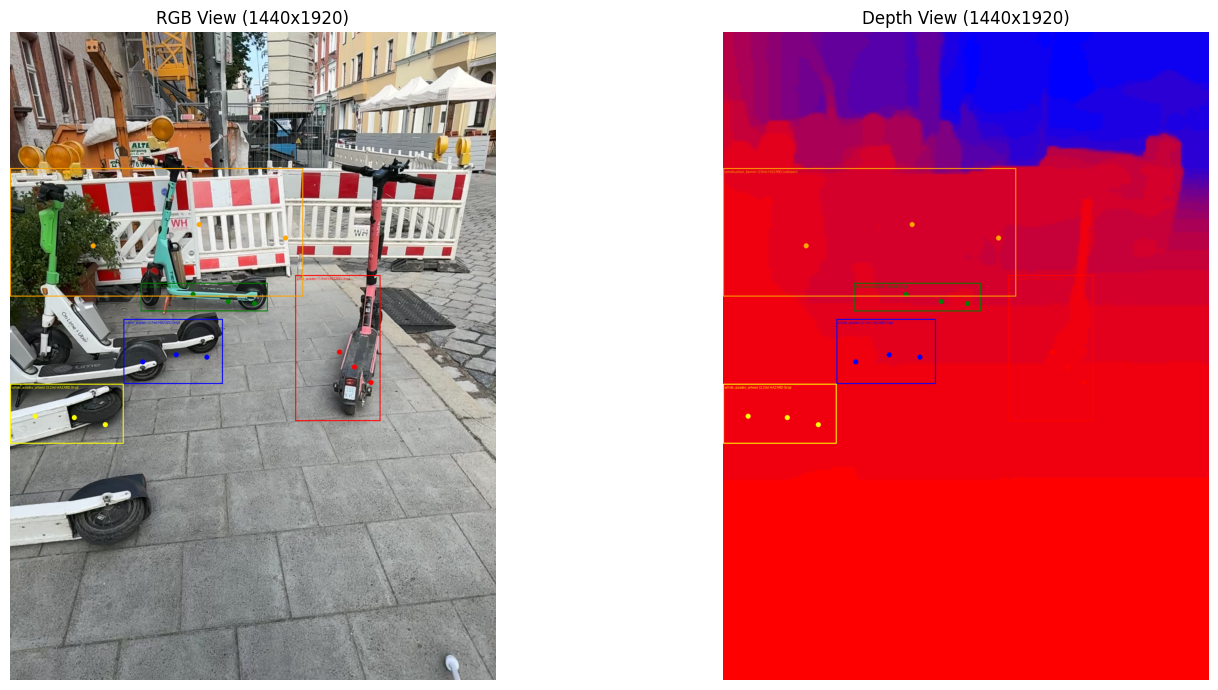

In [10]:
from IPython.display import display


# Reload and inspect the final output as a Python object
latest = pipeline.get_latest_output()
CONSOLE.plog(latest)
display(latest.visualization)


In [5]:
pipeline = pipeline_config.setup_target()


VisualizationOut(
    visualization=<PIL.PngImagePlugin.PngImageFile image mode=RGBA size=1218x690 at 0x300949A10>,
    object_count=6,
)

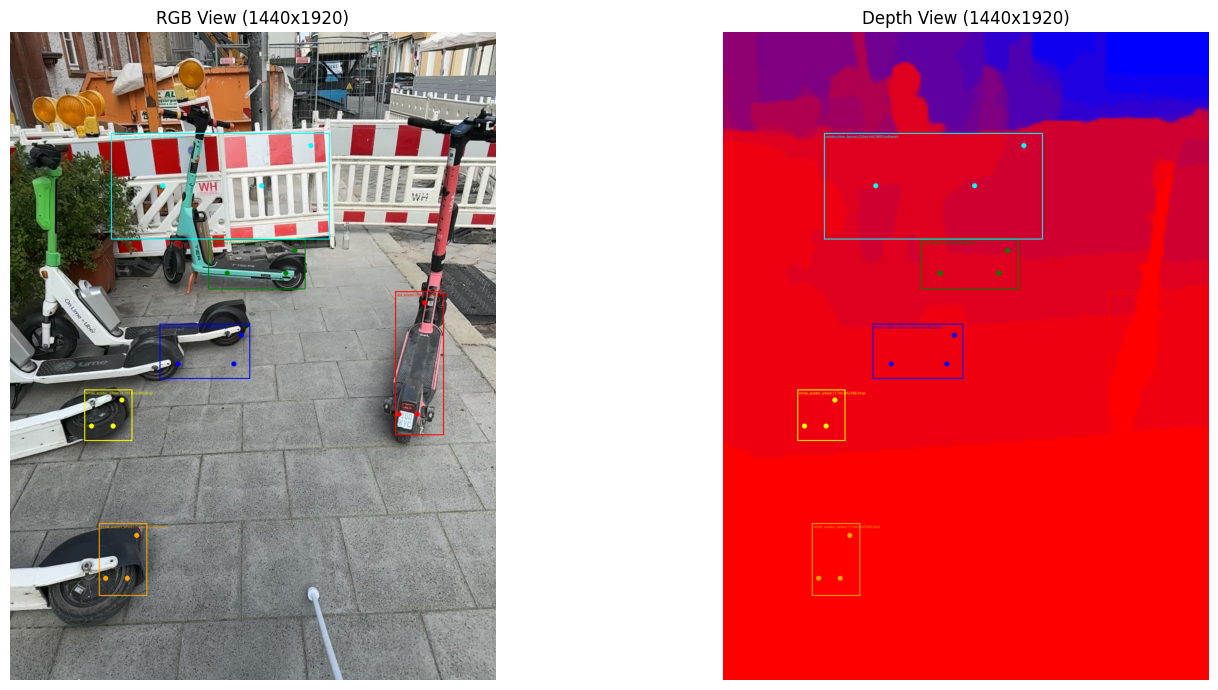

In [6]:
from IPython.display import display


# Reload and inspect the final output as a Python object
latest = pipeline.get_latest_output()
CONSOLE.plog(latest)
display(latest.visualization)


In [7]:
pipeline.get_names()

{'SpatialUnderstandingPipeline-2025_04_29-09_45_05_457138': ['StrayDataset',
  'GeminiVLMDetection',
  'get_visualization_in',
  'SceneVisualizer']}

In [8]:
pipeline.get_output_of_stage("GeminiVLMDetection")

DetectionStageOut(objects=[DetectedObject(aabb_2d=[400, 793, 622, 893], points_2d=[(590, 838), (590, 800), (418, 853)], label='red_scooter', approx_distance=1.8, height='floor-level', description='A red scooter is 1.8 meters ahead, slightly to the right.', is_hazard=True, is_dynamic=False, hazard_type='trip'), DetectedObject(aabb_2d=[320, 408, 397, 608], points_2d=[(372, 568), (372, 447), (337, 586)], label='teal_scooter', approx_distance=2.5, height='floor-level', description='A teal scooter is 2.5 meters ahead, to the left.', is_hazard=True, is_dynamic=False, hazard_type='trip'), DetectedObject(aabb_2d=[450, 308, 535, 494], points_2d=[(512, 461), (512, 346), (468, 476)], label='white_scooter_wheel', approx_distance=2.0, height='floor-level', description='A white scooter wheel is 2.0 meters ahead, to the left.', is_hazard=True, is_dynamic=False, hazard_type='trip'), DetectedObject(aabb_2d=[552, 153, 631, 252], points_2d=[(608, 212), (608, 168), (568, 230)], label='white_scooter_wheel'